# 6. Graph Theory

## 6.1 Introduction to Graphs

**Graph**

A *graph* $G = (V, E)$ consists of $V$, a non-empty set of *vertices* (or *nodes*), and $E$, a set of *edges*, which are unordered pairs of elements of $V$. *Graphs* are often referred to as *networks*, particularly in the context of real world applications, for example, social networks, where vertices represent people and edges the relationships between them.

Vertices can be represented as circles and edges as lines connecting the corresponding vertices. An edge $(x,y)$, which can also be represented by $xy$,
is said to have the endpoints $x$ and $y$. $x$ and $y$ are said to be *neighbours* of each other.

Here's an example illustrating how to create the graph consisting of vertices $V = \{a, b, c, d\}$ and edges $E = \{(a,b),(a,d),(b,c),(c,d)\}$ in Python using the package NetworkX. Online [NetworkX resources](https://networkx.org/documentation/stable/) include a tutorial and, in particular, reference documentation for using various functions.

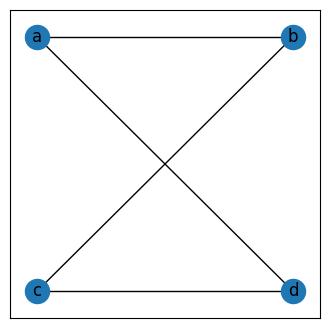

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create Graph
G = nx.Graph()

# Specify vertices
V = ["a","b","c","d"]
G.add_nodes_from(V)

# Specify Edges
E = [("a","b"),("a","d"),("b","c"),("c","d")]
G.add_edges_from(E)

# Display
plt.figure(1,figsize=(4,4)) # only needed to specify figure size
pos = {"a":(1,2), "b":(2,2), "c":(1,1), "d":(2,1)} # positions of vertices
nx.draw_networkx(G, pos) # nx.draw_networkx(G) if not worried about position of vertices

plt.show()

**Looped Graph**

Sometimes it is useful to have a vertex connected to itself. Such edges are called *loops* and give rise to *looped graphs* (see nodes $a$ and $d$ in the figure below).

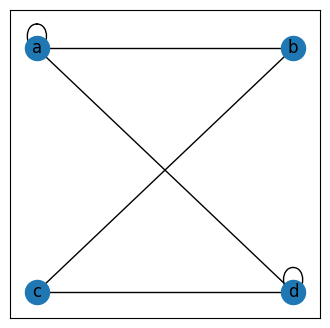

In [ ]:
# Extend the graph G above by adding loops
# First take a copy of the original graph
GL = G.copy()

# Add loops for a and d
E_extra = [("a","a"),("d","d")]
GL.add_edges_from(E_extra)

# Now display it
plt.figure(1,figsize=(4,4))
nx.draw_networkx(GL, pos)

plt.show()

**Multigraph**

It can also be useful in some graphs to have multiple edges between the same pair of vertices. Such a graphs are called *multigraphs* (see the additional edges between $b$ and $c$ and between $c$ and $d$ in the following graph).

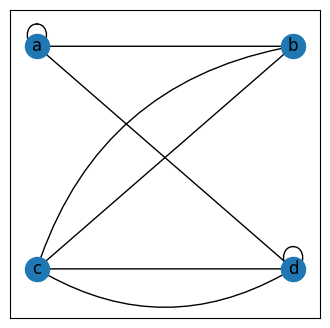

In [ ]:
# Create MultiGraph (actually a MultiDiGraph is used to make it easier to display)
GM = nx.MultiDiGraph()

# Add vertices from V
GM.add_nodes_from(V)

# Specify Edges
E = [("a","a"),("a","b"),("a","d"),("b","c"),("c","d"),("d","d")]
GM.add_edges_from(E)

# Display
plt.figure(1,figsize=(4,4))
nx.draw_networkx(GM, pos, arrowstyle='-')

# Add second edge between b and c and between c and d
E_extra = [("b","c"),("c","d")]
GM.add_edges_from(E_extra)

# Add new edges to display
nx.draw_networkx_edges(GM, pos, edgelist=E_extra, connectionstyle='arc3,rad=0.3', arrowstyle='-')

plt.show()

**Directed Graph**

A *directed graph* $G = (V,E)$ is a graph in which the edges $E$ are ordered
pairs of elements of $V$. The edges (or *arcs*) are represented by arrows. For
example, the directed graph consisting of vertices $V = \{a, b, c, d\}$ and edges $E = \{(a,b),(a,d),(b,c),(c,d),(d,c)\}$ can be represented as follows. (Note that since both $(c,d)$ and $(d,c) \in E$, there are arrows going in both directions between these vertices.)

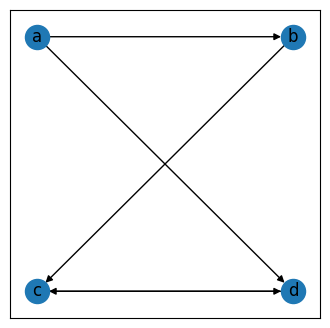

In [ ]:
# Create Directed Graph - a DiGraph in NetworkX
GD = nx.DiGraph()

# Add vertices from V
GD.add_nodes_from(V)

# Specify Directed Edges
E = [("a","b"),("a","d"),("b","c"),("c","d"),("d","c")]
GD.add_edges_from(E)

# Display
plt.figure(1,figsize=(4,4))
nx.draw_networkx(GD, pos)
plt.show()

**Subgraph**

If $G = (V,E)$ is a graph, then a graph $H = (W,F)$, where $W \subseteq V$ and $F \subseteq E$, is a *subgraph* of $G$. If $H \neq G$, then $H$ is a proper subgraph of $G$.

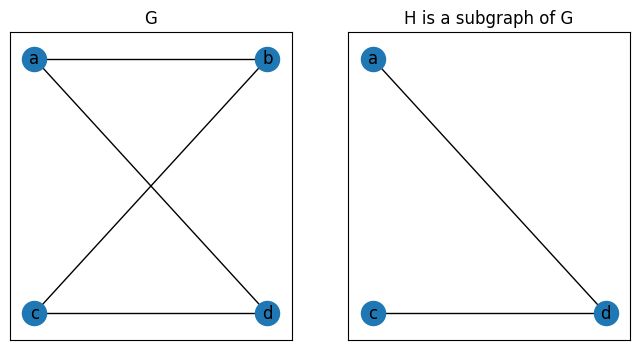

In [ ]:
# Create Graph H
H = nx.Graph()

# Specify vertices
W = ["a","c","d"]
H.add_nodes_from(W)

# Specify Edges
F = [("a","d"),("c","d")]
H.add_edges_from(F)

# Display
pos_H = {"a":(1,2), "c":(1,1), "d":(2,1)} # positions for G
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4))
nx.draw_networkx(G, pos, ax=ax1)
nx.draw_networkx(H, pos_H, ax=ax2)
ax1.set_title('G')
ax2.set_title('H is a subgraph of G')
plt.show()

**Degree of a Vertex**

The *degree of a vertex* $v$, denoted $deg(v)$, is the number of edges that have $v$ as an endpoint. For example, in the graph below, $deg(a) = 2, deg(b) = 3, deg(c) = 1, deg(d) = 2$. The code illustrates how to determine the degree of a given vertex or for all of the vertices.

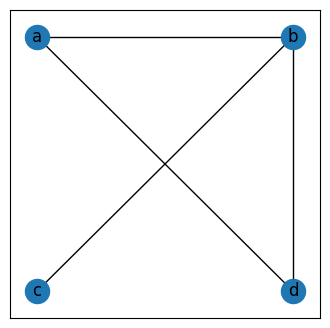

Degree of b:  3
All degrees:  [('a', 2), ('b', 3), ('c', 1), ('d', 2)]


In [ ]:
# Create Graph
G2 = nx.Graph()

# Add vertices from V
G2.add_nodes_from(V)

# Specify Edges
E = [("a","b"),("a","d"),("b","c"),("b","d")]
G2.add_edges_from(E)

# Display
plt.figure(1,figsize=(4,4))
nx.draw_networkx(G2, pos)
plt.show()

print('Degree of b: ', G2.degree["b"])
print('All degrees: ', G2.degree)

**Handshaking Theorem**

The sum of the degrees of all vertices in an undirected graph $G=(V,E)$ is equal to twice the number of edges, $2|E|$, i.e.

$
\displaystyle\sum\limits_{i=1}^{|V|} \, deg(v_i) = 2|E|.
$

**Exercise 6.1**

Explain why the Handshaking theorem is true.

**Walks, Paths and Cycles**

A *walk* in a graph $G$ is a finite sequence of vertices $v_0, v_1, ..., v_n$ and edges $e_1, e_2. ..., e_n$ of $G$:

> $v_0, e_1, v_1, e_2; ..., e_n, v_n$,

where the endpoints of $e_i$ are $v_{i-1}$ and $v_i$ for each $i$. The length of a walk is its number of edges, so the walk shown above is of length $n$. A *simple walk* is a walk in which no edge is repeated. A *path* is a walk in which no vertex is repeated. In the graph below, the bold line highlights a walk from $a$ to $b$ to $c$ to $d$, which we can denote $abcd$. Note that this is a simple walk and also a path.

A $cycle$ is a simple walk in which the first and last vertices are the same and no other vertex is repeated. So in the graph below $abcda$ would be a cycle.

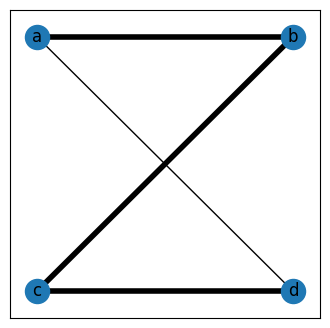

In [ ]:
# Display graph G
plt.figure(1,figsize=(4,4))
nx.draw_networkx(G, pos)

# Specify edges for walk abcd
E_walk = [("a","b"),("b","c"),("c","d")]
G.add_edges_from(E_walk)

# Display walk abcd
nx.draw_networkx_edges(G, pos, edgelist=E_walk, width=4)

plt.show()

**Weighted Graph**

A *weighted graph* is a graph where every edge has a weight associated with it. Formally, we can define a weighted graph $GW = (V,E,W)$, where $W = \{w_e: e\in E\}$. Weights can be used to represent various types of relationships between vertices, e.g. distances between locations, times to travel between locations, costs of travel, etc. The following shows how to add and display weights using the NetworkX package.

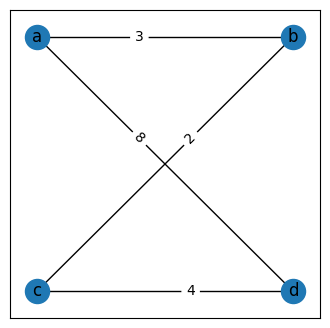

In [ ]:
# Create Graph
GW = nx.Graph()

# Specify weighted edges
EW = [("a", "b", {'weight': 3}), ("a", "d", {'weight': 8}),\
      ("b", "c", {'weight': 2}), ("c", "d", {'weight': 4})]
GW.add_edges_from(EW)

# Display
plt.figure(1,figsize=(4,4))
nx.draw_networkx(GW, pos)
labels = nx.get_edge_attributes(GW,'weight')
nx.draw_networkx_edge_labels(GW, pos, edge_labels=labels, label_pos=0.6)

plt.show()

**Connected Vertices and Connected Graph**

Two vertices are *connected* when there is walk joining them. A graph $G$ is connected if all pairs of its vertices are connected. (If a graph is disconnected, it will contain separate components each of which is connected.) The graph below has two components since $a$ and $b$ are not connected to the other vertices. The code uses functions from the NetworkX package to determine whether the graph is connected, how many components it has and what vertices are in each component.

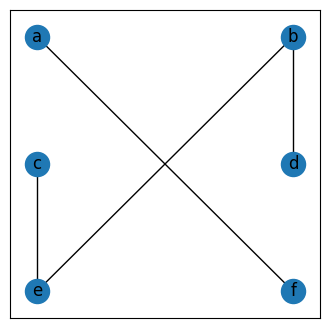

Graph connected:  False
Number of components:  2
{'a', 'f'}
{'d', 'c', 'e', 'b'}


In [ ]:
# Create Graph
GC = nx.Graph()

# Specify Vertices
VC = {"a","b","c","d","e","f"}
GC.add_nodes_from(VC)

# Specify Edges
E = [("a","f"),("b","d"),("b","e"),("c","e")]
GC.add_edges_from(E)

# Display
plt.figure(1,figsize=(4,4))
pos_GC = pos = {"a":(1,2), "b":(2,2), "c":(1,1), "d":(2,1), "e":(1,0), "f":(2,0)}
nx.draw_networkx(GC, pos_GC)
plt.show()

print('Graph connected: ', nx.is_connected(GC))
print('Number of components: ', nx.number_connected_components(GC))
for component in nx.connected_components(GC):
    print(component)

**Tree**

A *tree* is a *connected graph* containing no *cycles*. Equivalently, a tree can be defined as a graph that has a unique *simple walk* between any two of its vertices.

**Exercise 6.2**

Determine whether each of the graphs displayed below is a tree.

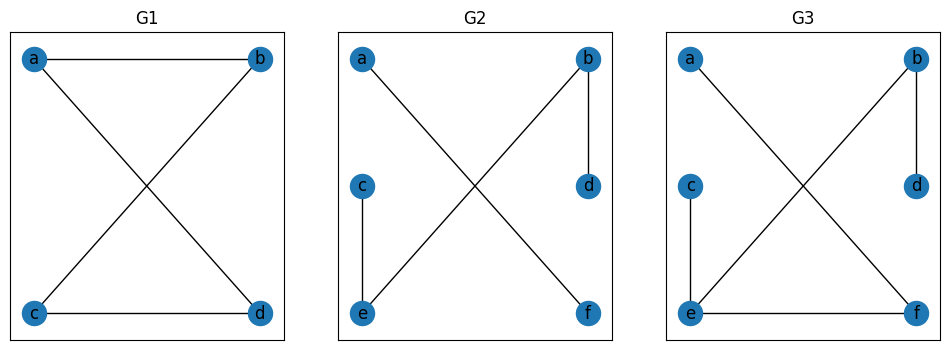

In [ ]:
# Display
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))
nx.draw_networkx(G, pos, ax=ax1)
nx.draw_networkx(GC, pos_GC, ax=ax2)

G3 = GC.copy()
G3.add_edge("e","f")
nx.draw_networkx(G3, pos_GC, ax=ax3)
ax1.set_title('G1')
ax2.set_title('G2')
ax3.set_title('G3')
plt.show()



You can check your solutions using the NetworkX function `is_tree` to determine whether a graph is a tree:

`print('G1 Tree: ', nx.is_tree(G))`


**Rooted Tree**

A *rooted* tree is a tree in which one vertex has been designated the root and
every edge is directed away from the root. For example, consider G3 above. The figures below show G3 as rooted tree with $e$ and $f$ as roots respectively. (Note that G3 is unchanged in terms of vertices and edges; only its presentation has changed.)

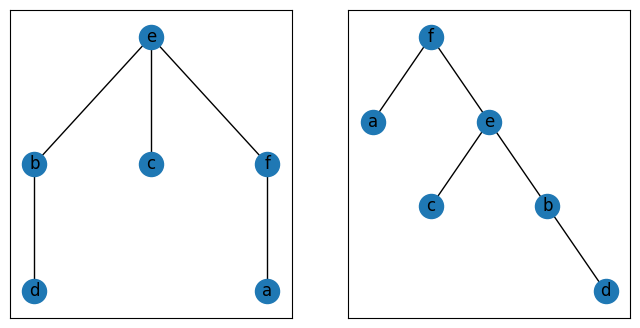

In [ ]:
# Display
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4))

# Specify positions for e as root vertex and display
pos_e = {"e":(1,2), "b":(0,1), "c":(1,1), "f":(2,1), "a":(2,0), "d":(0,0)}
nx.draw_networkx(G3, pos_e, ax=ax1)

# Specify positions for e as root vertex and display
pos_f = {"f":(1,2), "a":(0,1), "e":(2,1), "c":(1,0), "b":(3,0), "d":(4,-1)}
nx.draw_networkx(G3, pos_f, ax=ax2)

plt.show()

## 6.2 Adjacency Matrices

So far the edges of a graph have been specified as a list, but matrices provide a straightforward way to represent graphs. First, consider a matrix representation for an undirected graph.

**Adjacency Matrix**

For an undirected graph $G=(V,E)$, an *adjacency matrix* $A$ is a square matrix consisting of $0$s and $1$s where a $1$ in row $i$, column $j$ ($A_{i,j}=1$) represents an edge between vertex $i$ and vertex $j$ whereas a $0$ ($A_{i,j}=0$) represents the absence of an edge.

Consider the following adjacency matrix:

$A = \begin{bmatrix} 1 & 1 & 0 & 1  \\\ 1 & 0 & 0 & 1 \\\ 0 & 0 & 1 & 1 \\\ 1 & 1 & 1 & 0 \end{bmatrix}$

The idea is that each row (and each column) corresponds to a vertex of the graph.

Note that the adjacency matrix is symmetric, $A_{i,j} = A_{j,i}$. This is because for an undirected graph, if there is an edge between vertices $i$ and $j$ there is also an edge between vertices $j$ and $i$.

The code below shows how to convert the matrix $A$ into its corresponding graph.




[[1 1 0 1]
 [1 0 0 1]
 [0 0 1 1]
 [1 1 1 0]]
[0, 1, 2, 3]
[(0, 0), (0, 1), (0, 3), (1, 3), (2, 2), (2, 3)]


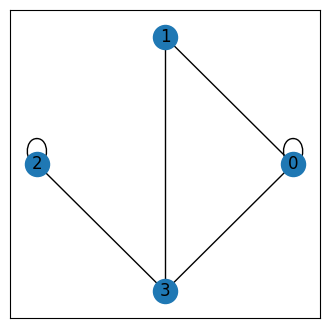

In [ ]:
import numpy as np

# Create Adjacency matrix
A = np.array([[1, 1, 0, 1], [1, 0, 0, 1], [0, 0, 1, 1],[1, 1, 1, 0]])
print(A)

# Create graph from adjacency matrix
GM = nx.from_numpy_array(A)

# Display graph information
print(GM.nodes)
print(GM.edges)

# Display the graph
plt.figure(1,figsize=(4,4))
posM = nx.circular_layout(GM)
nx.draw_networkx(GM, posM)

plt.show()

**Note**: the vertices are labelled 0, 1, 2 and 3, so that the first row (and column) in the matrix represents vertex 0.

Consider the first row of the adjacency matrix:

*   The first entry (1) indicates that vertex 0 is connected to itself.
* The second entry (1) indicates that vertex 0 is connected to vertex 1.
* The third entry (0) indicates that vertex 0 is not connected to vertex 2.
* The fourth entry (1) indicates that vertex 0 is connceted to vertex 3.

**Adjacency Matrix for a Directed Graph**

This is the same as an adjacency matrix except that now a $1$ in row $i$, column $j$ represents a *directed* between vertices $i$ and $j$.

Note that in this case the adjacency matrix does not need to be symmetric since there can be a directed edge from $i$ to $j$ but not from $j$ to $i$.

Consider the following adjacency matrix:

$A = \begin{bmatrix} 0 & 1 & 1 & 0  \\\ 0 & 0 & 0 & 1 \\\ 0 & 1 & 0 & 1 \\\ 1 & 0 & 0 & 0 \end{bmatrix}$

The following code shows how to generate the corresponding directed graph.

[[0 1 1 0]
 [0 0 0 1]
 [0 1 0 1]
 [1 0 0 0]]
[0, 1, 2, 3]
[(0, 1), (0, 2), (1, 3), (2, 1), (2, 3), (3, 0)]


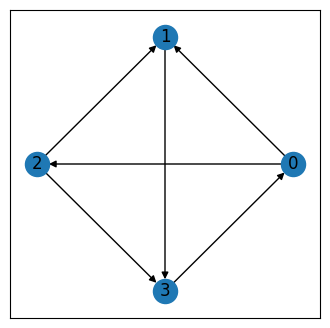

In [ ]:
# Create Adjacency matrix
A = np.array([[0, 1, 1, 0], [0, 0, 0, 1], [0, 1, 0, 1],[1, 0, 0, 0]])
print(A)

# Create graph from adjacency matrix
GM = nx.from_numpy_array(A,create_using=nx.DiGraph)

# Display graph information
print(GM.nodes)
print(GM.edges)

# Display the graph
plt.figure(1,figsize=(4,4))
posM = nx.circular_layout(GM)
nx.draw_networkx(GM, posM)

plt.show()

**Weighted Adjacency Matrix**

This is just the same as a an adjacency matrix except that now non-zero values can be used to represent the weights between two vertices. For example, consider the following matrix:

$A = \begin{bmatrix} 1 & 2 & 0 & 5  \\\ 2 & 0 & 0 & 8 \\\ 0 & 0 & 1 & 1 \\\ 5 & 8 & 1 & 0 \end{bmatrix}$

[[1 2 0 5]
 [2 0 0 8]
 [0 0 1 1]
 [5 8 1 0]]
[0, 1, 2, 3]
[(0, 0, {'weight': 1}), (0, 1, {'weight': 2}), (0, 3, {'weight': 5}), (1, 3, {'weight': 8}), (2, 2, {'weight': 1}), (2, 3, {'weight': 1})]


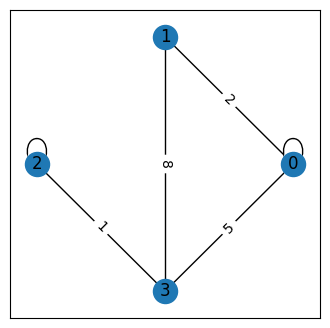

In [ ]:
# Create Adjacency matrix
A = np.array([[1, 2, 0, 5], [2, 0, 0, 8], [0, 0, 1, 1],[5, 8, 1, 0]])
print(A)

# Create graph from adjacency matrix
GM = nx.from_numpy_array(A)

# Display graph information
print(GM.nodes)
print(GM.edges(data=True))

# Display the graph
plt.figure(1,figsize=(4,4))
posM = nx.circular_layout(GM)
nx.draw_networkx(GM, posM)
labels = nx.get_edge_attributes(GM,'weight')
nx.draw_networkx_edge_labels(GM, posM, edge_labels=labels)

plt.show()

**Note 1.** Weighted adjacency matrices can also be used for directed graphs.

**Note 2.** What we have called a weighted adjacency matrix could instead be used to define a multigraph. In this case, $A_{i,j}$ representes the number of edges between vertices $i$ and $j$. So instead of a weighting of 2 between vertices $0$ and $1$ in the graph above, there would be two separate edges between these vertices.

**Exercise 6.3**

Specify an adjacency matrix for the following graph.

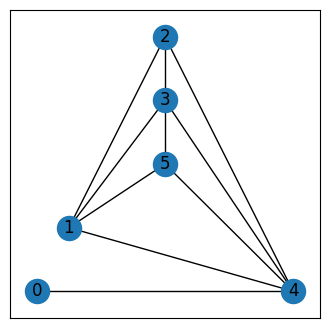



## 6.3 Shortest Paths

Many problems can be represented in terms of finding the shortest path between two vertices in a weighted graph. For example, finding the shortest route to travel between two cities or, if the weights represent time, the shortest travel time between two cities.

Consider the weighted graph below. We'll assume for simplicity that the weights represent distances. It might seem strange that a direct route between two vertices can be longer than an indirect route via another vertex, e.g. $v_1$-$v_7$-$v_3$ is shorter than $v_1$-$v_3$. But suppose vertices represent cities. Then it could be that the road going 'directly' from $v_1$ to $v_3$ is not really so direct at all, perhaps it goes through a mountainous region, whereas travelling via $v_7$ is much more straightforward.


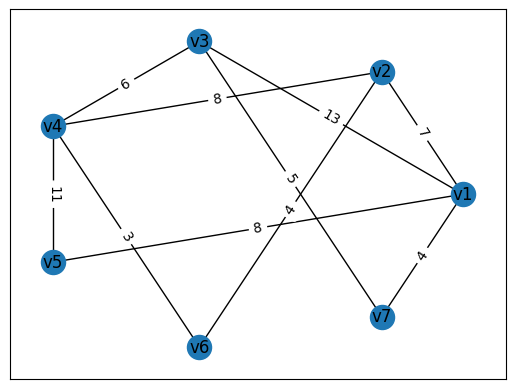

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create Graph
GP = nx.Graph()

# Specify vertices
VP = ["v1","v2","v3","v4","v5","v6","v7"]
GP.add_nodes_from(VP)

# Specify Edges
EP = [("v1", "v2", {'w': 7}), ("v1", "v3", {'w': 13}),\
      ("v1", "v5", {'w': 8}), ("v1", "v7", {'w': 4}),\
      ("v2", "v6", {'w': 4}), ("v3", "v4", {'w': 6}),\
      ("v4", "v5", {'w': 11}), ("v4", "v6", {'w': 3}),\
      ("v3", "v7", {'w': 5}), ("v2", "v4", {'w': 8}),
     ]
GP.add_edges_from(EP)

# Display
pos = nx.circular_layout(GP)
nx.draw_networkx(GP, pos)
labels = nx.get_edge_attributes(GP,'w')
nx.draw_networkx_edge_labels(GP, pos, labels)

plt.show()

**Exercise 6.4**

Find all the paths (i.e. no vertex is repeated) between vertices $v_1$  and $v_4$ in the above graph.

Hence find the shortest path between $v_1$ and $v_4$.

**Finding Shortest Paths with Brute Force**

One approach to solving the problem is to use brute force but as we shall see this turns out to be a poor strategy.

Consider the weighted graph below and suppose we want to find the shortest path between $v_1$ and $v_2$. (This example and the discussion below is based on chapter 9 of *Practical Discrete Mathematics* by White et al. Please consult it for further details.)


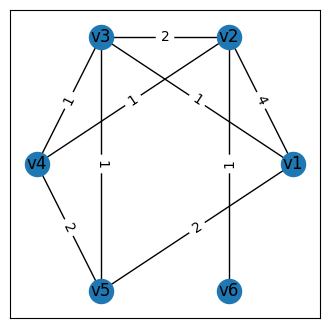

In [ ]:
# Create Graph
GP2 = nx.Graph()

# Specify vertices
VP2 = ["v1","v2","v3","v4","v5","v6"]
GP2.add_nodes_from(VP2)

# Specify Edges
EP2 = [("v1", "v2", {'w': 4}), ("v1", "v3", {'w': 1}),\
      ("v1", "v5", {'w': 2}), ("v2", "v3", {'w': 2}),\
      ("v2", "v4", {'w': 1}), ("v2", "v6", {'w': 1}),\
      ("v3", "v4", {'w': 1}), ("v3", "v5", {'w': 1}),\
      ("v4", "v5", {'w': 2})]
GP2.add_edges_from(EP2)

# Display
plt.figure(1,figsize=(4,4)) # only needed to specify figure size
pos = nx.circular_layout(GP2)
nx.draw_networkx(GP2, pos)
labels = nx.get_edge_attributes(GP2,'w')
nx.draw_networkx_edge_labels(GP2, pos, labels)

plt.show()

We could simply identify all the paths between these vertices along with their lengths to get the following results:

| Paths from $v_1$ to $v_2$ | Path Lengths |
|---|---|
|$v_1$-$v_2$|4|
|$v_1$-$v_3$-$v_2$|1+2=3|
|$v_1$-$v_3$-$v_4$-$v_2$|1+1+1=3|
|$v_1$-$v_3$-$v_5$-$v_4$-$v_2$|1+1+2+1=5|
|$v_1$-$v_5$-$v_3$-$v_2$|2+1+2=5|
|$v_1$-$v_5$-$v_4$-$v_2$|2+2+1=5|
|$v_1$-$v_5$-$v_4$-$v_3$-$v_2$|2+2+1+2=5|

<br>

Clearly, there are two shortest paths of length 3: $v_1$-$v_3$-$v_2$ and $v_1$-$v_3$-$v_4$-$v_2$.

While this approach works in this case, it scales very badly. In other words, for larger graphs there are to many possible paths between vertices for it to be feasible.

To illustrate, suppose we consider a complete graph which has edges between each pair of vertices. How many paths would there be between a pair of vertices? If there are 6 vertices, there would be 16 paths. For 10 vertices, there would be 8,192 paths, for 20 vertices 262,000 paths and for 100 vertices about 3.17 x 10<sup>29</sup> paths, so this is infeasible even with powerful computers.

**Dijkstra's algorithm**

Starting from vertex $v_1$, which is called the source, Dijkstra's algorithm will actually give us the shortest path from $v_1$ to every other vertex. We need to maintain two lists: vertices that have been visited so far and the unvisited vertices. Initially, the visited set is empty, so for our example problem we have:

*   Visited vertices: {}
*   Univsitied vertices: {$v_1,v_2,v_3,v_4,v_5,v_6$}

Dijkstra's algorithm proceeds as follows:

*   Initialization: Set the distance to each vertex from the source to infinity and the distance to itself as 0.
*   Visit the nearest unvisited adjacent vertex with the shortest known distance from the source (ties can be broken arbitrarily):\
a) If any distances through the current vertex from the source are shorter than the known distances, update the shortest distances.\
b) For any replaced shortest distances, record the "previous vertex" as the current vertex.\
c) Add the current vertex to the visited vertices list.
*   Repeat the work from the previous bullet point until we have visited all of the vertices.

Let's apply the algorithm to our example problem.

Initially the distances are as follows:

| Vertex | Shortest Distance | Previous Vertex |
|---|---|---|
|$v_1$|0||
|$v_2$|$\infty$||
|$v_3$|$\infty$||
|$v_4$|$\infty$||
|$v_5$|$\infty$||
|$v_6$|$\infty$||

**Step 1:** add the source $v_1$ to the set of visited vertices and find the distance from it to all of the adjacent vertices in the unvisited set. Since $v_1$ is adjacent to $v_2$, $v_3$ and $v_5$ this gives the following table:

| Vertex | Shortest Distance | Previous Vertex |
|---|---|---|
|$v_1$|0||
|$v_2$|4|$v_1$|
|$v_3$|1|$v_1$|
|$v_4$|$\infty$||
|$v_5$|2|$v_1$|
|$v_6$|$\infty$||



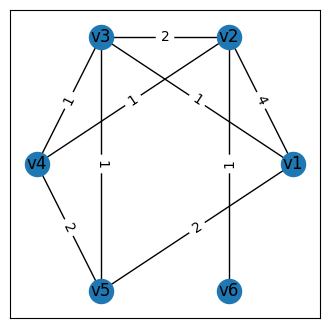

In [ ]:
# Display
plt.figure(1,figsize=(4,4)) # only needed to specify figure size
pos = nx.circular_layout(GP2)
nx.draw_networkx(GP2, pos)
labels = nx.get_edge_attributes(GP2,'w')
nx.draw_networkx_edge_labels(GP2, pos, labels)

plt.show()

**Step 2:** visit the vertex with the shortest distance from the source so far. From the table above, that is $v_3$ so it gets added to visted set giving:

*   Visited vertices: {$v_1,v_3$}
*   Unvisited vertices: {$v_2,v_4,v_5,v_6$}

and then we find the distances from the source through $v_3$ to each unvisited vertex and replace any distances that are shortened. This gives:

| Vertex | Shortest Distance | Previous Vertex |
|---|---|---|
|$v_1$|0||
|$v_2$|1+2=3|$v_3$|
|$v_3$|1|$v_1$|
|$v_4$|1+1=2|$v_3$|
|$v_5$|2|$v_1$|
|$v_6$|$\infty$||

**Step 3:** repeat step 2. This time both $v_4$ and $v_5$ have distance 2, so we arbitrarily choose $v_4$ to get:

*   Visited vertices: {$v_1,v_3,v_4$}
*   Unvisited vertices: {$v_2,v_5,v_6$}

and

| Vertex | Shortest Distance | Previous Vertex |
|---|---|---|
|$v_1$|0||
|$v_2$|3|$v_3$|
|$v_3$|1|$v_1$|
|$v_4$|2|$v_3$|
|$v_5$|2|$v_1$|
|$v_6$|$\infty$||

Continuing in this way (see chapter 9 of *Practical Discrete Mathematics* by White et al for details), by step 6 we have visited all the vertices, so that

*   Visited vertices: {$v_1,v_2,v_3,v_4,v_5,v_6$}
*   Unvisited vertices: {}

and we get the table:

| Vertex | Shortest Distance | Previous Vertex |
|---|---|---|
|$v_1$|0||
|$v_2$|3|$v_3$|
|$v_3$|1|$v_1$|
|$v_4$|2|$v_3$|
|$v_5$|2|$v_1$|
|$v_6$|4|$v_2$|

The table tells us that the shortest distance from $v_1$ to $v_2$ is 3 and the last edge of the shortest path is the edge from $v_3$ to $v_2$. The previous vertex from $v_3$ of its shortest path is $v_1$ so the shortest path found by the algorithm is:

$v_1$-$v_3$-$v_2$

**Finding the Shortest Path in Python using NetworkX**

The NetworkX package provides [functions for finding shortest paths](https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html).

In [ ]:
# For the graph GP2 defined earlier with weights given by w

print("Shortest path:", nx.shortest_path(G=GP2, source='v1', target='v2', weight='w'))

print("Length of shortest path:", nx.shortest_path_length(G=GP2, source='v1', target='v2', weight='w'))

Shortest path: ['v1', 'v3', 'v2']
Length of shortest path: 3
